In [ ]:
import os
import shutil
import yaml
import random
import glob
from pathlib import Path
try:
    import roboflow
except ImportError:
    !pip install -q roboflow
    import roboflow

# --- CONFIGURATION ---
API_KEY = 'nJNt3iQCSmnLCuv0NrEX'
UNIFIED_YAML = {
    'names': ['cattle', 'lumpy_skin', 'foot_and_mouth', 'mastitis'],
    'nc': 4,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images'
}

DATASETS = [
    {"workspace": "atc-gyqoh", "project": "lumpy-skin-mdtsn", "version": 2, "target": "lumpy_skin"},
    {"workspace": "yuossef", "project": "lumpy-skin-diesease", "version": 6, "target": "lumpy_skin"},
    {"workspace": "moaz-ahmen", "project": "foot-and-mouth-disease-mfuiw", "version": 1, "target": "foot_and_mouth"},
    {"workspace": "non-fmzye", "project": "name1-mb7nq", "version": 1, "target": "foot_and_mouth"},
    {"workspace": "cow-udder", "project": "deteksi-mastitis-sapi", "version": 3, "target": "mastitis"},
    {"workspace": "kirubel-yemane", "project": "cow-and-mastitis-detection", "version": 18, "target": "mixed"} # Contains both
]

MERGED_DIR = Path('merged_dataset')
for split in ['train', 'val', 'test']:
    (MERGED_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (MERGED_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

In [ ]:
rf = roboflow.Roboflow(api_key=API_KEY)

def get_unified_id(label_name):
    label_name = label_name.lower()
    if 'lumpy' in label_name: return 1
    if 'foot' in label_name or 'mouth' in label_name or 'fmd' in label_name: return 2
    if 'mastitis' in label_name: return 3
    return 0 # Default to cattle if detected but not diseased

for ds_info in DATASETS:
    print(f"Downloading {ds_info['project']}...")
    project = rf.workspace(ds_info['workspace']).project(ds_info['project'])
    dataset = project.version(ds_info['version']).download("yolov8")

    # Load original yaml for mapping
    with open(Path(dataset.location) / 'data.yaml', 'r') as f:
        orig_data = yaml.safe_load(f)
        orig_names = orig_data.get('names', [])

    # Process each split
    for split in ['train', 'valid', 'test']:
        src_split = 'valid' if split == 'valid' else split
        dst_split = 'val' if split == 'valid' else split

        img_files = glob.glob(str(Path(dataset.location) / src_split / 'images' / '*'))
        for img_path in img_files:
            img_name = os.path.basename(img_path)
            lbl_name = os.path.splitext(img_name)[0] + '.txt'
            src_lbl = Path(dataset.location) / src_split / 'labels' / lbl_name

            if not src_lbl.exists(): continue

            # Remap labels
            new_lines = []
            with open(src_lbl, 'r') as f:
                for line in f:
                    parts = line.split()
                    orig_idx = int(parts[0])
                    orig_label = orig_names[orig_idx] if isinstance(orig_names, list) else orig_names.get(orig_idx, "")
                    new_idx = get_unified_id(orig_label)
                    new_lines.append(f"{new_idx} {' '.join(parts[1:])}\n")

            # Save to merged
            shutil.copy(img_path, MERGED_DIR / dst_split / 'images' / img_name)
            with open(MERGED_DIR / dst_split / 'labels' / lbl_name, 'w') as f:
                f.writelines(new_lines)

print("Merging complete. Writing data.yaml...")
with open(MERGED_DIR / 'data.yaml', 'w') as f:
    yaml.dump(UNIFIED_YAML, f)

loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
Merging complete. Writing data.yaml...


In [ ]:
import sys
import time
import requests
from pathlib import Path
from tqdm.auto import tqdm  # Auto-selects Notebook or Terminal progress bar

# Ensure MERGED_DIR is a Path object
MERGED_DIR = Path(MERGED_DIR)

# Ensure target directories exist
(MERGED_DIR / 'train' / 'images').mkdir(parents=True, exist_ok=True)
(MERGED_DIR / 'train' / 'labels').mkdir(parents=True, exist_ok=True)

# Count positive samples
train_images = list((MERGED_DIR / 'train' / 'images').glob('*'))
num_total_positives = len(train_images)

if num_total_positives == 0:
    print(f"⚠️ Warning: Found 0 positive images in {MERGED_DIR / 'train' / 'images'}. Check your directory path!")

num_negatives = int(num_total_positives * 0.08) if num_total_positives > 0 else 50 # Default to 50 if zero found
print(f"Target: Download {num_negatives} negative samples (based on {num_total_positives} positive images).")

session = requests.Session()
# Add a real browser User-Agent to avoid 403 Forbidden blocks
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
})

success_count = 0
failed_count = 0

pbar = tqdm(total=num_negatives, desc="Downloading Backgrounds")

for i in range(num_negatives):
    neg_img_name = f"background_{i}.jpg"
    neg_lbl_name = f"background_{i}.txt"

    img_path = MERGED_DIR / 'train' / 'images' / neg_img_name
    lbl_path = MERGED_DIR / 'train' / 'labels' / neg_lbl_name

    # Try LoremFlickr first; fallback to Picsum Photos if blocked/rate-limited
    urls_to_try = [
        f"https://loremflickr.com/640/640/farm,pasture,field?random={i}",
        f"https://picsum.photos/640/640?random={i}"
    ]

    downloaded = False
    for url in urls_to_try:
        try:
            response = session.get(url, timeout=8)
            if response.status_code == 200 and len(response.content) > 1000:
                with open(img_path, 'wb') as f:
                    f.write(response.content)

                # Create empty label file for YOLO
                with open(lbl_path, 'w') as f:
                    pass

                downloaded = True
                break
        except Exception as err:
            continue

    if downloaded:
        success_count += 1
        pbar.update(1)
    else:
        failed_count += 1
        pbar.write(f"❌ Failed to download sample {i}")

    # Short delay to prevent hitting server rate limits (HTTP 429)
    time.sleep(0.15)

pbar.close()

print(f"\nFinished! Added {success_count} background samples to {MERGED_DIR}.")
if failed_count > 0:
    print(f"⚠️ {failed_count} downloads failed due to network or rate limits.")

Target: Download 515 negative samples (based on 6443 positive images).



Finished! Added 515 background samples to merged_dataset.


In [ ]:
import os
import cv2
import torch
from ultralytics import YOLO

# Disable internal OpenCV multi-threading to prevent RAM fragmentation
cv2.setNumThreads(0)

# Wrap in main block for safe execution
if __name__ == '__main__':
    # 1. Hardware Verification
    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    print(f"🚀 Using Device: {device}")
    if device.startswith('cuda'):
        print(f"GPU Model: {torch.cuda.get_device_name(0)}")
        print(f"VRAM Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

    # 2. Load Base Checkpoint
    model = YOLO('yolov8s.pt')

    # 3. Train Model
    results = model.train(
        # --- DATASET & CORE CONFIG ---
        data='merged_dataset/data.yaml',
        epochs=120,               # Maximum epochs; early stopping will cut off when converged
        patience=25,              # Stops if no mAP50-95 improvement for 25 consecutive epochs
        imgsz=640,                # Input image resolution
        batch=4,                  # Explicit batch size for 4GB VRAM
        workers=0,                # FIXED: 0 runs data loading in main process, preventing OpenCV MemoryError
        device=device,
        cache=False,              # Keeps raw images off RAM caching

        # --- OPTIMIZER & LR SCHEDULER ---
        optimizer='auto',
        lr0=0.01,
        cos_lr=True,
        warmup_epochs=3.0,

        # --- ANTI-OVERFITTING & REGULARIZATION ---
        weight_decay=0.0005,
        dropout=0.1,

        # --- AUGMENTATIONS ---
        mosaic=1.0,
        mixup=0.15,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=10.0,
        fliplr=0.5,

        # --- HARDWARE & OUTPUT ---
        amp=True,                 # FP16 Precision
        project='yolo_smart_diag',
        name='cattle_gate_v1',
        exist_ok=True,
        plots=True
    )

    # 4. Final Test Set Evaluation
    print("\n--- 📊 Evaluating Best Model Weights on Test Set ---")
    best_model_path = os.path.join(results.save_dir, 'weights', 'best.pt')
    best_model = YOLO(best_model_path)

    test_metrics = best_model.val(data='merged_dataset/data.yaml', split='test', workers=0)

    print("\n--- Final Metrics ---")
    print(f"Path to Best Model: {best_model_path}")
    print(f"Test mAP50:    {test_metrics.box.map50:.4f}")
    print(f"Test mAP50-95: {test_metrics.box.map:.4f}")

🚀 Using Device: cuda:0
GPU Model: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM Available: 4.29 GB
New https://pypi.org/project/ultralytics/8.4.117 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.47  Python-3.12.7 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=merged_dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4

Displaying main results plot from: C:\Users\lasit\runs\detect\yolo_smart_diag\cattle_gate_v1\results.png


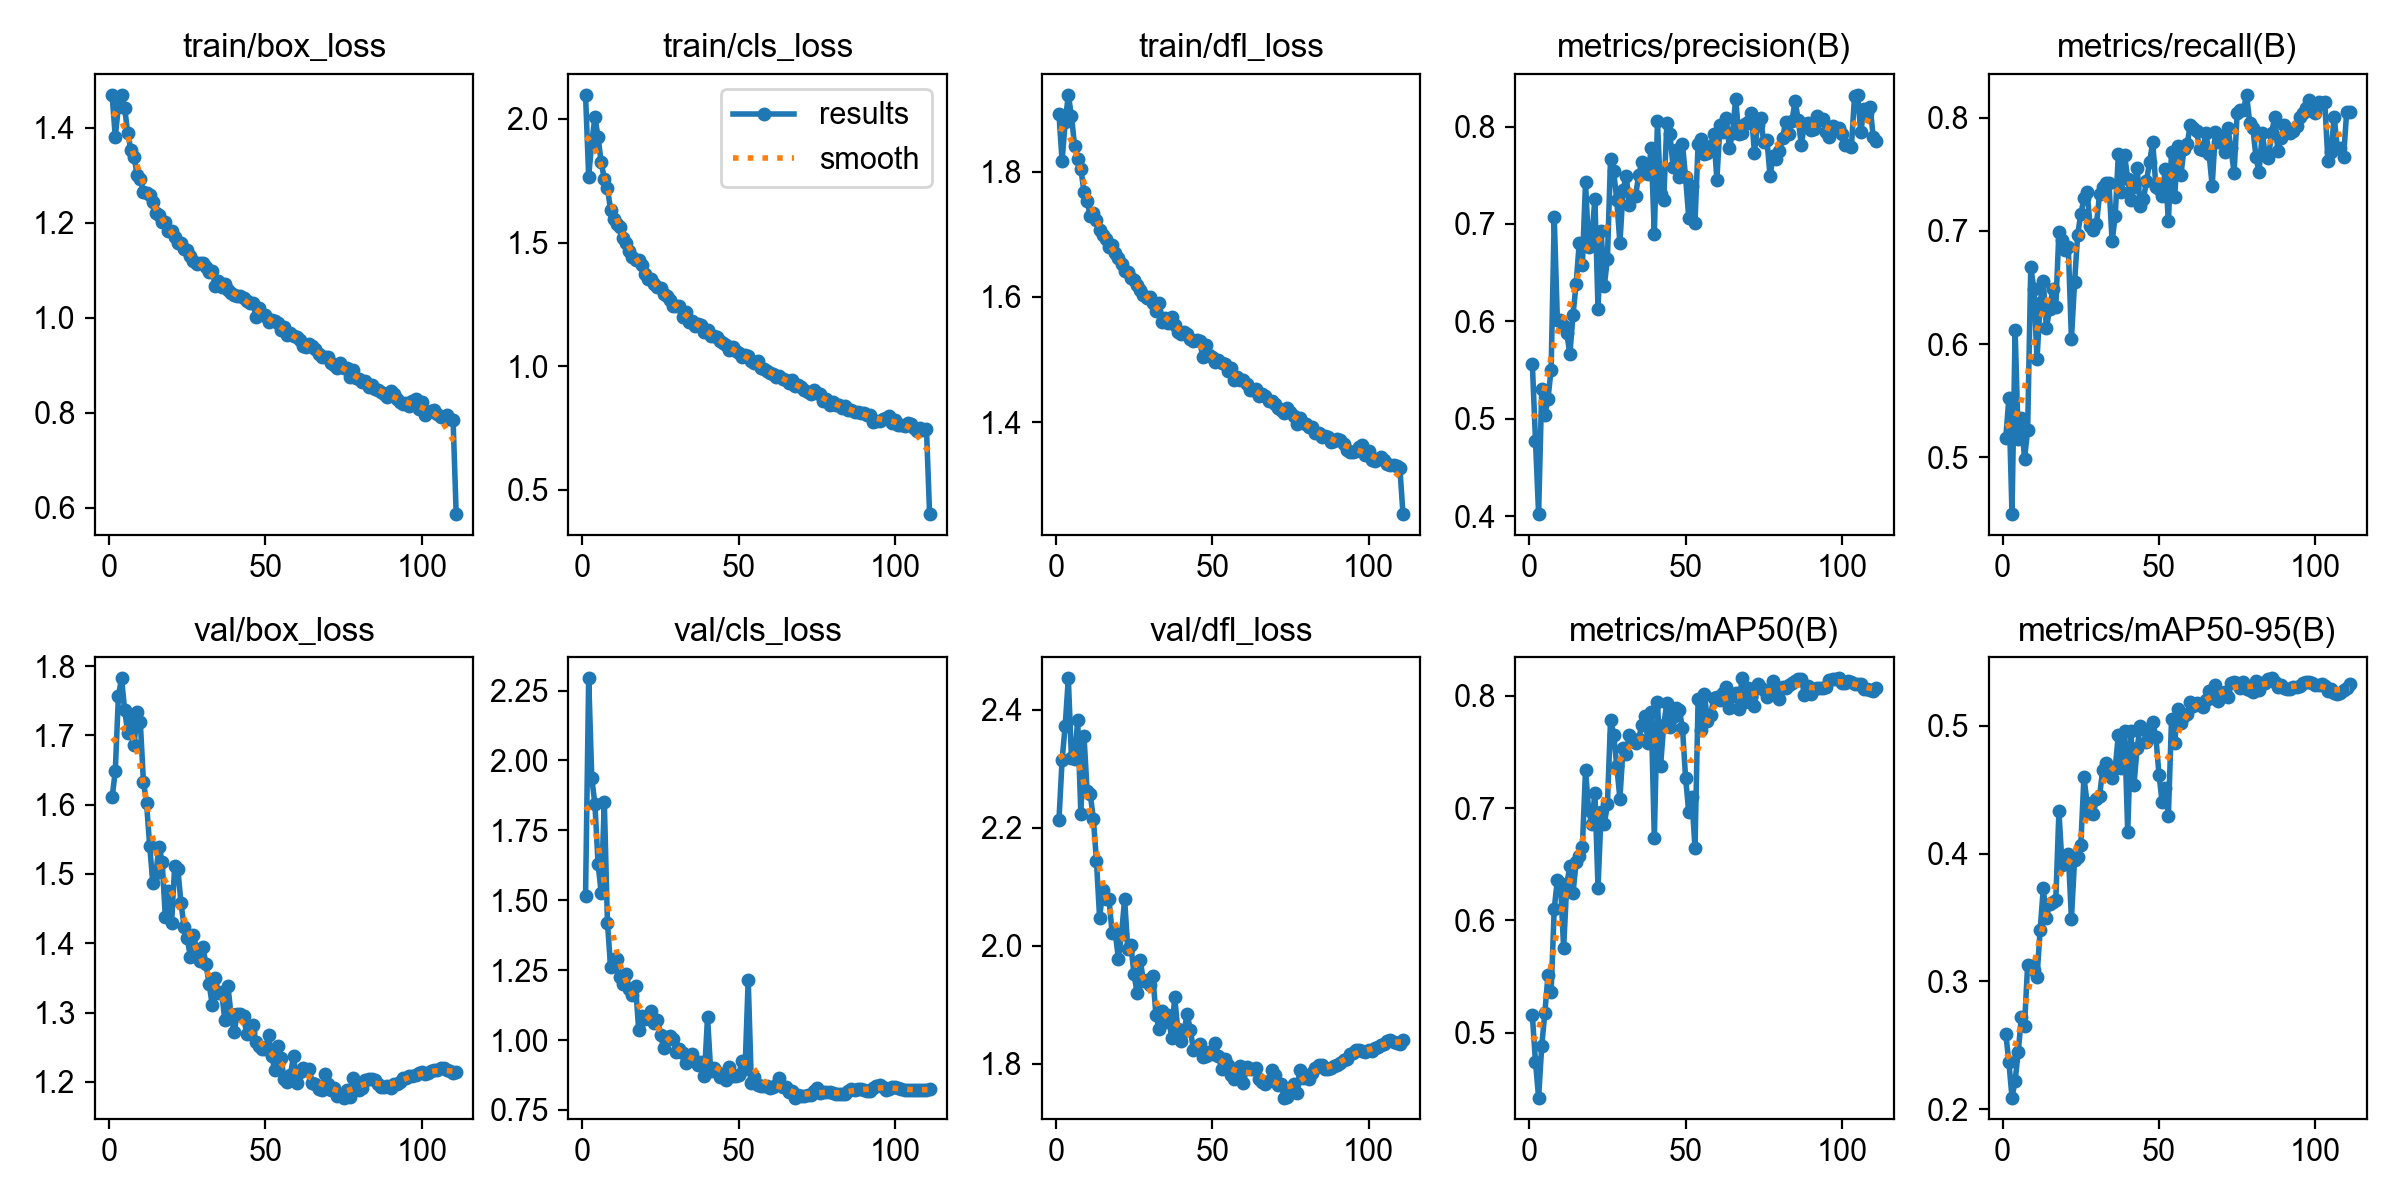

In [6]:
from IPython.display import Image, display
import os

# Define the save_dir explicitly based on the training output
save_dir = r'C:\Users\lasit\runs\detect\yolo_smart_diag\cattle_gate_v1'

# Construct the path to results.png which is often the main consolidated plot
results_png_path = os.path.join(save_dir, 'results.png')

if os.path.exists(results_png_path):
    print(f"Displaying main results plot from: {results_png_path}")
    display(Image(filename=results_png_path))
else:
    print(f"Main results plot (results.png) not found at: {results_png_path}")
    print(f"Contents of main save directory ({save_dir}):")
    if os.path.exists(save_dir):
        found_plots = False
        for item in os.listdir(save_dir):
            if item.endswith('.png') or item.endswith('.jpg'):
                print(f"  - {item}")
                found_plots = True
        if not found_plots:
            print("No plot files (*.png or *.jpg) found in the save directory.")
    else:
        print(f"Main save directory not found at: {save_dir}")

In [17]:
import os
import cv2
from pathlib import Path
from ultralytics import YOLO

# --- CONFIGURATION ---
MODEL_PATH = r"C:\Users\lasit\runs\detect\yolo_smart_diag\cattle_gate_v1\weights\best.pt"

# Replace this with the path to the image you want to test
TEST_IMAGE_PATH = r"C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\images.jpg"

def run_gate_test(image_path: str, model_path: str, conf_threshold: float = 0.25):
    """
    Tests an input image against the fine-tuned YOLO gate model.
    Prints detection stats and saves cropped ROIs for downstream ViT processing.
    """
    if not os.path.exists(image_path):
        print(f"❌ Error: Input image path does not exist: {image_path}")
        return

    print(f"\n🔍 Running YOLO Gate Evaluation on: {image_path}")

    # 1. Load the fine-tuned model
    model = YOLO(model_path)

    # 2. Run inference
    results = model.predict(
        source=image_path,
        conf=conf_threshold,
        save=True,
        project="yolo_smart_diag",
        name="test_predictions",
        exist_ok=True
    )

    result = results[0]  # Single image result
    boxes = result.boxes

    # 3. Integrity Gate Logic
    if len(boxes) == 0:
        print("\n==================================================")
        print("🚫 GATE STATUS: REJECTED")
        print("Reason: No valid cattle or disease symptoms detected.")
        print("==================================================")
        return

    print("\n==================================================")
    print(f"✅ GATE STATUS: PASSED ({len(boxes)} region(s) detected)")
    print("==================================================")

    # 4. Extract Bounding Boxes & Save Cropped Regions for ViT
    orig_img = result.orig_img  # Loaded BGR OpenCV image
    output_crop_dir = Path("test_predictions/crops")
    output_crop_dir.mkdir(parents=True, exist_ok=True)

    for i, box in enumerate(boxes):
        cls_id = int(box.cls[0])
        cls_name = model.names[cls_id]
        conf = float(box.conf[0])

        # Bounding box coordinates [x1, y1, x2, y2]
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        print(f"  • Detection {i + 1}: Class='{cls_name}' | Confidence={conf:.2%} | Box=[{x1}, {y1}, {x2}, {y2}]")

        # Crop ROI for downstream Vision Transformer input
        crop_img = orig_img[y1:y2, x1:x2]
        crop_filename = output_crop_dir / f"crop_{i + 1}_{cls_name}.jpg"
        cv2.imwrite(str(crop_filename), crop_img)
        print(f"    └─ Saved cropped ROI to: {crop_filename}")

    # Output annotated image path
    annotated_dir = Path(result.save_dir)
    print(f"\n📸 Annotated full image saved to folder: {annotated_dir}")

if __name__ == "__main__":
    run_gate_test(TEST_IMAGE_PATH, MODEL_PATH)


🔍 Running YOLO Gate Evaluation on: C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\images.jpg

image 1/1 C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\images.jpg: 640x640 (no detections), 15.2ms
Speed: 5.3ms preprocess, 15.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\lasit\runs\detect\yolo_smart_diag\test_predictions

🚫 GATE STATUS: REJECTED
Reason: No valid cattle or disease symptoms detected.


### Analyzing Class Distribution
We will now scan the label files to count how many instances of each class exist in the training and validation sets to identify potential class imbalance.

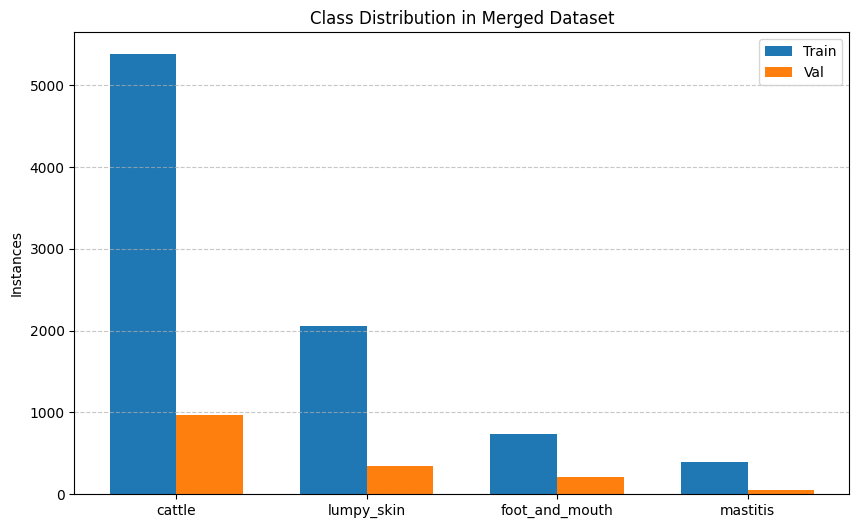

cattle: 6350 total instances (Train: 5380, Val: 970)
lumpy_skin: 2397 total instances (Train: 2058, Val: 339)
foot_and_mouth: 946 total instances (Train: 738, Val: 208)
mastitis: 447 total instances (Train: 399, Val: 48)


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import glob
from pathlib import Path
from collections import Counter

# Define variables that might have been lost in session scope
MERGED_DIR = Path('merged_dataset')
class_names = ['cattle', 'lumpy_skin', 'foot_and_mouth', 'mastitis']

def count_classes(label_path, class_names):
    counts = Counter()
    label_files = glob.glob(str(Path(label_path) / '*.txt'))

    for lbl in label_files:
        with open(lbl, 'r') as f:
            for line in f:
                parts = line.split()
                if parts:
                    class_id = int(parts[0])
                    counts[class_id] += 1
    return counts

train_counts = count_classes(MERGED_DIR / 'train' / 'labels', class_names)
val_counts = count_classes(MERGED_DIR / 'val' / 'labels', class_names)

# Prepare data for plotting
ids = sorted(list(set(list(train_counts.keys()) + list(val_counts.keys()))))
labels = [class_names[i] if i < len(class_names) else f'Unknown_{i}' for i in ids]
train_vals = [train_counts[i] for i in ids]
val_vals = [val_counts[i] for i in ids]

# Plotting
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, train_vals, width, label='Train')
ax.bar(x + width/2, val_vals, width, label='Val')

ax.set_ylabel('Instances')
ax.set_title('Class Distribution in Merged Dataset')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

for i, name in enumerate(labels):
    t_count = train_counts[ids[i]]
    v_count = val_counts[ids[i]]
    print(f"{name}: {t_count + v_count} total instances (Train: {t_count}, Val: {v_count})")